<a href="https://www.kaggle.com/code/nadezhdaemelyanova/start-ml-final-project-eda?scriptVersionId=312245935" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sqlalchemy import create_engine
import re
from collections import Counter
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

In [2]:
# оформление графиков

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# кастомный список стоп-слов для частотного анализа текстов

custom_stop_words = {
    # предлоги
    'a', 'an', 'and', 'of', 'in', 'to', 'for', 'on', 'with', 'at', 'by', 'from', 'up', 'down', 'off', 'over', 'under', 'into', 'through', 
    'during', 'without', 'against', 'among', 'between', 'about', 'after', 'before', 'above', 'below', 'across', 'along', 'around', 'behind', 
    'beneath', 'beside', 'beyond', 'inside', 'near', 'outside', 'per', 'plus', 'since', 'than', 'via', 'within',
    # союзы и связки
    'and', 'or', 'but', 'so', 'for', 'nor', 'yet', 'because', 'if', 'then', 'else', 'when', 'where', 'which', 'while', 'whilst', 'whereas', 
    'whether', 'either', 'neither', 'both', 'not', 'only', 'just', 'as', 'like', 'than', 'that', 'these', 'those', 'this', 'those', 'such', 'same', 
    'different', 'other', 'another',
    # местоимения
    'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them', 'my', 'your', 'his', 'her', 'its', 'our', 'their', 'mine', 'yours', 
    'hers', 'ours', 'theirs', 'myself', 'yourself', 'himself', 'herself', 'itself', 'ourselves', 'yourselves', 'themselves', 'who', 'whom', 'whose', 
    'which', 'what', 'whatever', 'whoever', 'whomever',
    # вспомогательные глаголы
    'be', 'am', 'are', 'is', 'was', 'were', 'being', 'been', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'get', 'gets', 'got', 
    'getting', 'go', 'goes', 'went', 'going', 'make', 'makes', 'made', 'making', 'see', 'sees', 'saw', 'seeing', 'say', 'says', 'said', 'saying', 
    'give', 'gives', 'gave', 'giving', 'find', 'finds', 'found', 'finding', 'think', 'thinks', 'thought', 'thinking',
    # частицы, артикли, местоимения-прилагательные
    'te', 'this', 'that', 'these', 'those', 'some', 'any', 'no', 'every', 'all', 'both', 'each', 'few', 'many', 'more', 'most', 'other', 'such', 
    'certain', 'several', 'various', 'neither', 'either', 'enough', 'plenty', 'little', 'less', 'much', 'lot', 'lots', 'a', 'an',
    # вопросительные слова
    'why', 'how', 'when', 'where', 'what', 'which', 'who', 'whom', 'whose',
    # прочие частотные
    'very', 'just', 'but', 'so', 'too', 'also', 'even', 'only', 'really', 'quite', 'rather', 'somewhat', 'almost', 'nearly', 'hardly', 'barely', 
    'scarcely', 'never', 'always', 'sometimes', 'often', 'usually', 'generally', 'specifically', 'particularly', 'especially', 'namely', 'indeed', 
    'surely', 'certainly', 'probably', 'perhaps', 'maybe', 'although', 'though', 'despite', 'nevertheless', 'nonetheless', 'otherwise', 'instead', 
    'meanwhile', 'furthermore', 'moreover', 'consequently', 'accordingly', 'hence', 'thus', 'therefore', 'then', 'now', 'here', 'there', 'wherever', 
    'everywhere', 'anywhere', 'nowhere', 'somewhere', 'anyway', 'anyhow', 'whatever', 'whenever', 'wherever', 'whichever', 'however', 'whomever'
}

# Загрузка данных
Изначальные данные хранятся в postgres базе данных karpov.courses. База данных представляет собой три связанные таблицы:
1. **user_data** - информация о пользователях (айди, пол, возраст, страна, город, экспериментальная группа, операционная система, источник)
2. **post_text_df** - информация о посте и его текстовое содержание (айди, топик, текст)
3. **feed_data** - информация о взаимодействиях (вторичные ключи для юзера и поста, время, действие (лайк или просмотр), таргет (был поставлен лайк или нет))

Для корректного построения рекомендательной системы было необходимо, чтобы все **163205 уникальных пользователя** попали в датасет, причем с как можно большим количеством строк. Взяла максимальный объем в 6кк строк для баланса между точностью будущих моделей, скоростью и доступными вычислительными мощностями.

Чтобы каждый раз заново не подключаться к базе данных при работе с ноутбуком, сохранила на будущее полученную таблицу `all_data.csv`.

In [4]:
# # подключаемся к базе данных, импортируем таблицы и смотрим на них

# query = """
# WITH user_ranked AS (
#     SELECT 
#         *,
#         ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp DESC) as user_rn,
#         ROW_NUMBER() OVER (ORDER BY timestamp DESC) as global_rn
#     FROM public.feed_data
# )
# SELECT *
# FROM user_ranked
# WHERE user_rn = 1
#    OR global_rn <= 6000000 - 163205
# ORDER BY timestamp DESC
# LIMIT 6000000
# """

# engine = create_engine(
#     "postgresql://login:password@"
#     "postgres.lab.karpov.courses:6432/startml"
# )

# with engine.connect() as connection:
#     user_data = pd.read_sql('SELECT * FROM public.user_data', con=connection)
#     post_text_df = pd.read_sql('SELECT * FROM public.post_text_df', con=connection)
#     feed_data = pd.read_sql(query, con=connection)

# df = (feed_data
#      .merge(user_data, on='user_id', how='left')
#      .merge(post_text_df, on='post_id', how='left')).drop(['user_rn', 'global_rn'], axis=1)

# df.to_csv('all_data.csv', index=False)

In [5]:
df = pd.read_csv('/kaggle/input/datasets/nadezhdaemelyanova/allcsv/all.csv', sep=';')
df.head()

,Unnamed: 0,timestamp,user_id,post_id,action,target,gender,age,country,city,exp_group,os,source,text,topic
0,0,2021-12-29 23:51:06,161289,879,view,0,1,18,Russia,Moscow,2,Android,organic,Youssou NDour wins music prize\n\nSenegalese m...,entertainment
1,1,2021-12-29 23:51:06,20156,3114,view,0,0,16,Russia,Asino,4,Android,ads,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid
2,2,2021-12-29 23:51:06,40577,305,view,0,1,37,Russia,Sursk,1,Android,ads,Call centre users lose patience\n\nCustomers t...,business
3,3,2021-12-29 23:51:06,134078,3927,view,0,1,38,Russia,Kemerovo,4,iOS,organic,Handwashing continues to play a huge role in s...,covid
4,4,2021-12-29 23:51:06,50842,5720,view,0,1,17,Russia,Leninsk-Kuznetskiy,4,iOS,ads,Nice combination of the giant monster and samu...,movie


In [6]:
df = df.drop('Unnamed: 0', axis=1)
df.to_csv('all_data.csv', index=False)

# EDA
## Общая информация о датасете
Оценила размер датасета, посмотрела информацию о колонках. 

Обработала переменную `timestamp` для дальнейшего анализа: выделила час и день недели (остальное брать посчитала бессмысленным, тк данные лежат в диапазоне двух месяцев)

In [7]:
# размер датасета
df.shape

(5890555, 14)

In [8]:
# информация о колонках: сразу видим, что нет пропусков
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5890555 entries, 0 to 5890554
Data columns (total 14 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   timestamp  object
 1   user_id    int64 
 2   post_id    int64 
 3   action     object
 4   target     int64 
 5   gender     int64 
 6   age        int64 
 7   country    object
 8   city       object
 9   exp_group  int64 
 10  os         object
 11  source     object
 12  text       object
 13  topic      object
dtypes: int64(6), object(8)
memory usage: 629.2+ MB


In [9]:
# наличие или отсутствие полных дубликатов
df.duplicated().sum()

np.int64(0)

In [10]:
# работа с timestamp

df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f"Исследуемый диапазон дат: с {df['timestamp'].min()} по {df['timestamp'].max()}")

Исследуемый диапазон дат: с 2021-10-27 16:42:51 по 2021-12-29 23:51:06


In [11]:
# получаем признаки из timestamp: час, день недели

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek  # 0=пн

df.head()

,timestamp,user_id,post_id,action,target,gender,age,country,city,exp_group,os,source,text,topic,hour,dayofweek
0,2021-12-29 23:51:06,161289,879,view,0,1,18,Russia,Moscow,2,Android,organic,Youssou NDour wins music prize\n\nSenegalese m...,entertainment,23,2
1,2021-12-29 23:51:06,20156,3114,view,0,0,16,Russia,Asino,4,Android,ads,#MadhyaPradeshCM #ShivrajSinghChouhan tests po...,covid,23,2
2,2021-12-29 23:51:06,40577,305,view,0,1,37,Russia,Sursk,1,Android,ads,Call centre users lose patience\n\nCustomers t...,business,23,2
3,2021-12-29 23:51:06,134078,3927,view,0,1,38,Russia,Kemerovo,4,iOS,organic,Handwashing continues to play a huge role in s...,covid,23,2
4,2021-12-29 23:51:06,50842,5720,view,0,1,17,Russia,Leninsk-Kuznetskiy,4,iOS,ads,Nice combination of the giant monster and samu...,movie,23,2


### Анализ взаимодействий колонок action и target
С первого взгляда на данные может показаться, что эти колонки являются дубликатами. Различие состоит в том, что `action` - это событие в потоке данных, и время относится именно к событию, а `target` - это конечный факт, связывающий конкретного пользователя с конктерным постом (стоит лайк или нет).

In [12]:
# сводная таблица частот для этих двух колонок

pd.crosstab(df['action'], df['target'])

target,0,1
action,,
like,708969,0
view,4476995,704591


Вывод: `target = 1` в строке с `view` означает, что этот конкретный просмотр привел к лайку в будущем. А сама строка с `action = 'like'` помечена нулем, чтобы избежать лика данных при обучении модели.

## Анализ категориальных признаков
Посмотрела описательные статистики, визуализировала частоты категорий и связь с таргетной переменной

In [13]:
# описательные статистики категориальных признаков

cat_cols = ['action', 'target', 'gender', 'country', 'city', 'exp_group', 'os', 'source', 'topic']
df[cat_cols] = df[cat_cols].astype(object)
df[cat_cols].describe()

,action,target,gender,country,city,exp_group,os,source,topic
count,5890555,5890555,5890555,5890555,5890555,5890555,5890555,5890555,5890555
unique,2,2,2,11,3915,5,2,2,7
top,view,0,1,Russia,Moscow,2,Android,ads,movie
freq,5181586,5185964,3264436,5130218,816715,1206000,3823372,3669151,2181587


Сразу видно по описательным статистикам action и target, что пользователи ставят мало лайков. Мне кажется, это типичное поведение для большей части соцсетей.

In [14]:
# для визуализации города оставила три категории: Москва, СПБ и other
frequent_cities = ['Moscow', 'Saint Petersburg']
df['city_visual'] = df['city'].where(df['city'].isin(frequent_cities), 'Оther')

In [15]:
# для визуализации страны юзера оставила три категории: Россия, Украина и other
frequent_countries = ['Russia', 'Ukraine']
df['country_visual'] = df['country'].where(df['country'].isin(frequent_countries), 'Оther')

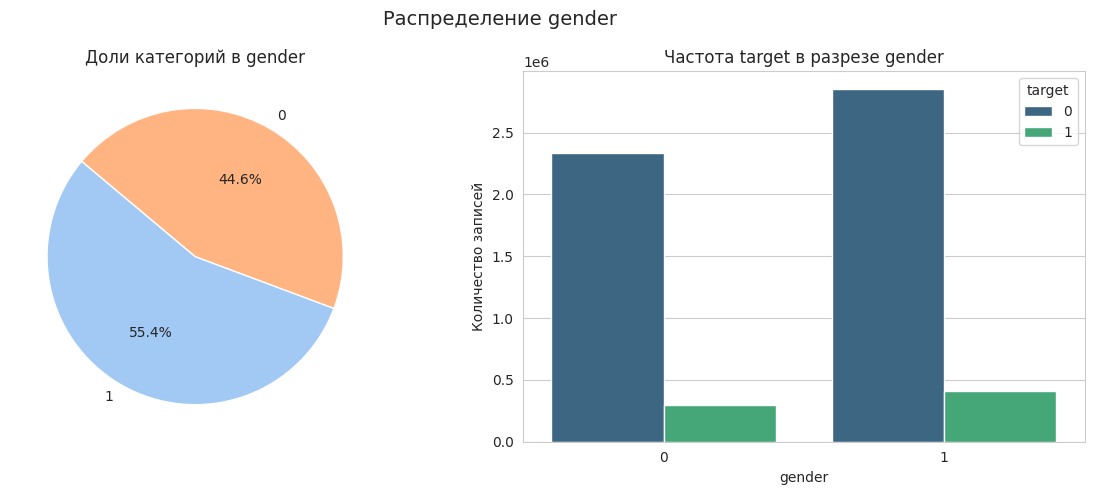

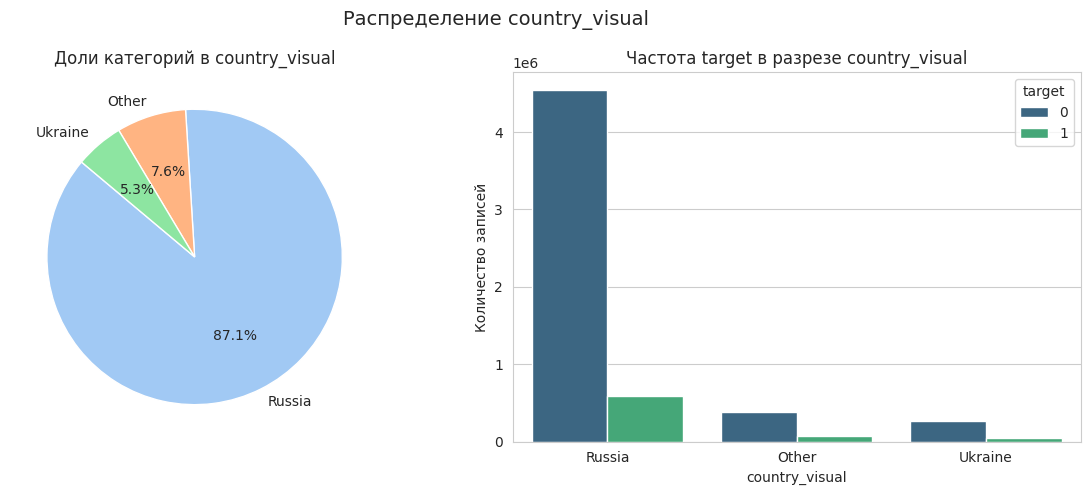

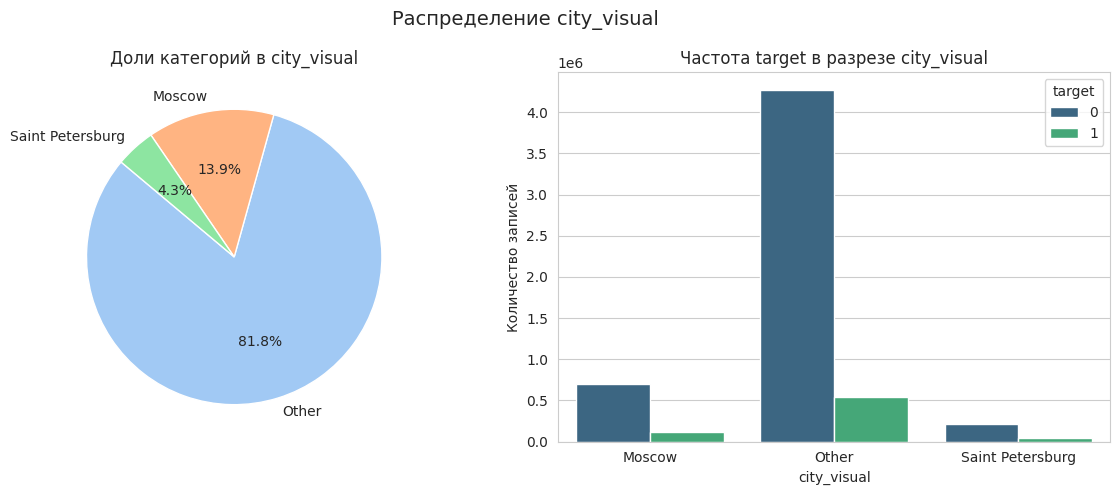

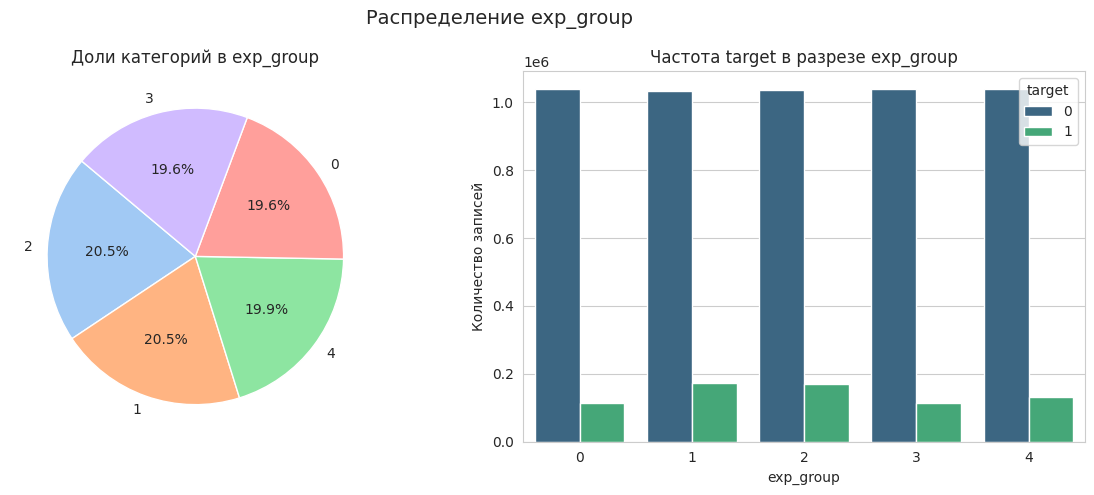

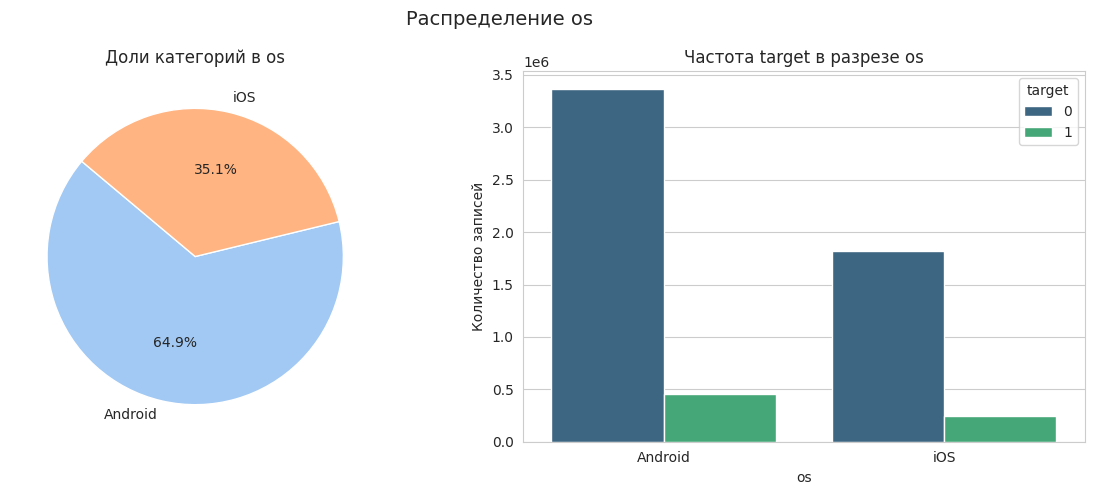

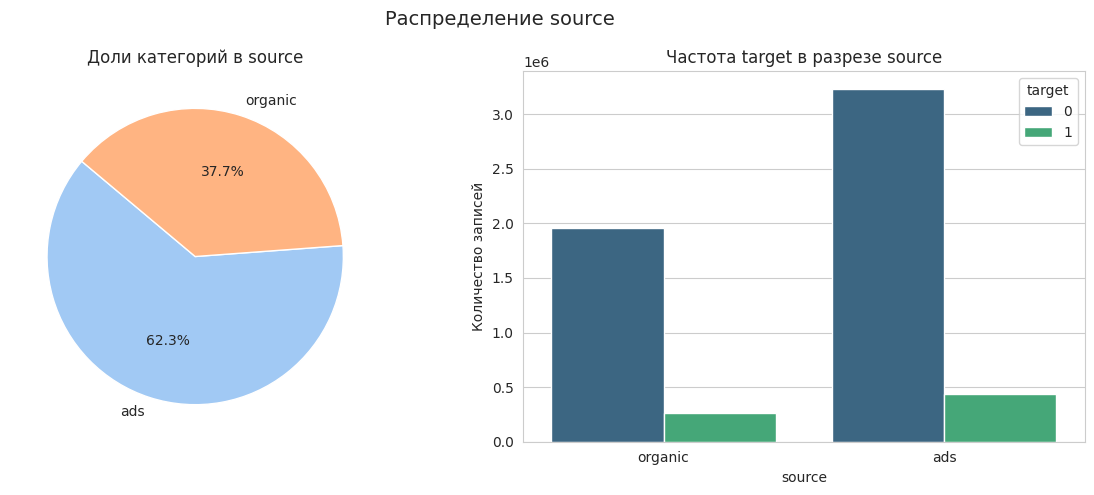

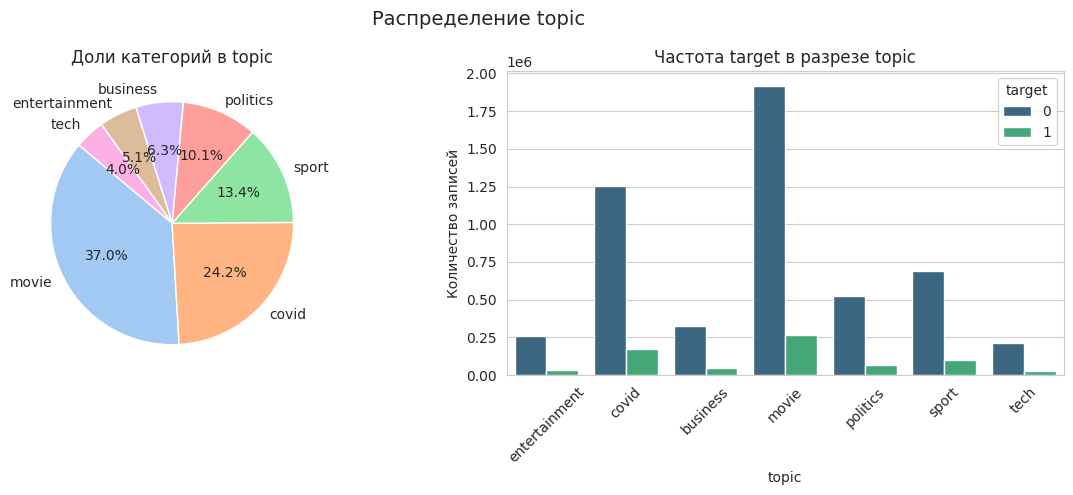

In [16]:
# берем cat_cols кроме таргета и action и строим диаграммы

for col in ['gender', 'country_visual', 'city_visual', 'exp_group', 'os', 'source', 'topic']:
    fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig1.suptitle(f'Распределение {col}', fontsize=14)
    
    counts = df[col].value_counts()
    ax1.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
    ax1.set_title(f'Доли категорий в {col}')
    
    sns.countplot(data=df, x=col, hue='target', ax=ax2, palette='viridis')
    ax2.set_title(f'Частота target в разрезе {col}')
    ax2.set_xlabel(col)
    ax2.set_ylabel('Количество записей')

    # поворачиваем подписи, если категорий много
    if df[col].nunique() > 5:
        ax2.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

## Анализ количественных признаков

Посмотрела на распределение возраста и данных из timestamp относительно таргета

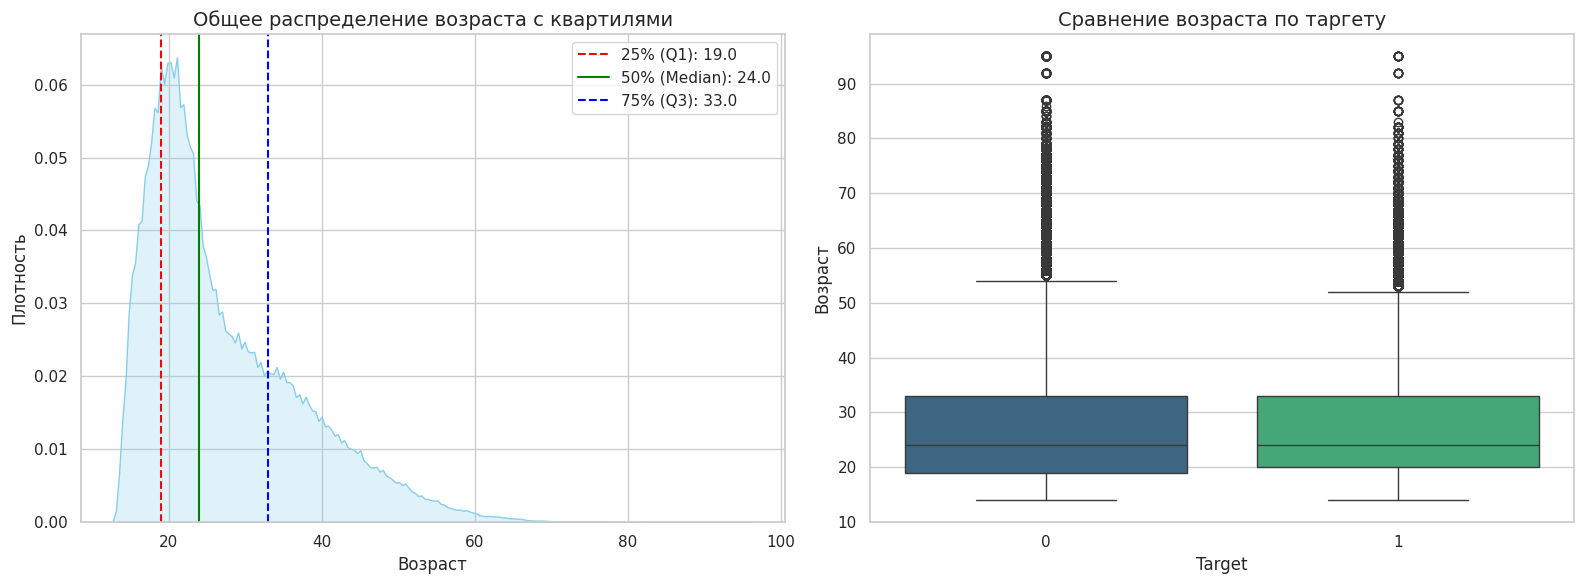

In [17]:
sns.set_theme(style="whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.kdeplot(data=df, x='age', fill=True, ax=ax1, color='skyblue')
q1, median, q3 = df['age'].quantile([0.25, 0.5, 0.75])
ax1.axvline(q1, color='red', linestyle='--', label=f'25% (Q1): {q1:.1f}')
ax1.axvline(median, color='green', linestyle='-', label=f'50% (Median): {median:.1f}')
ax1.axvline(q3, color='blue', linestyle='--', label=f'75% (Q3): {q3:.1f}')
ax1.set_title('Общее распределение возраста с квартилями', fontsize=14)
ax1.set_xlabel('Возраст')
ax1.set_ylabel('Плотность')
ax1.legend()

sns.boxplot(data=df, x='target', y='age', ax=ax2, palette='viridis', hue='target', legend=False)

ax2.set_title('Сравнение возраста по таргету', fontsize=14)
ax2.set_xlabel('Target')
ax2.set_ylabel('Возраст')

plt.tight_layout()
plt.show()

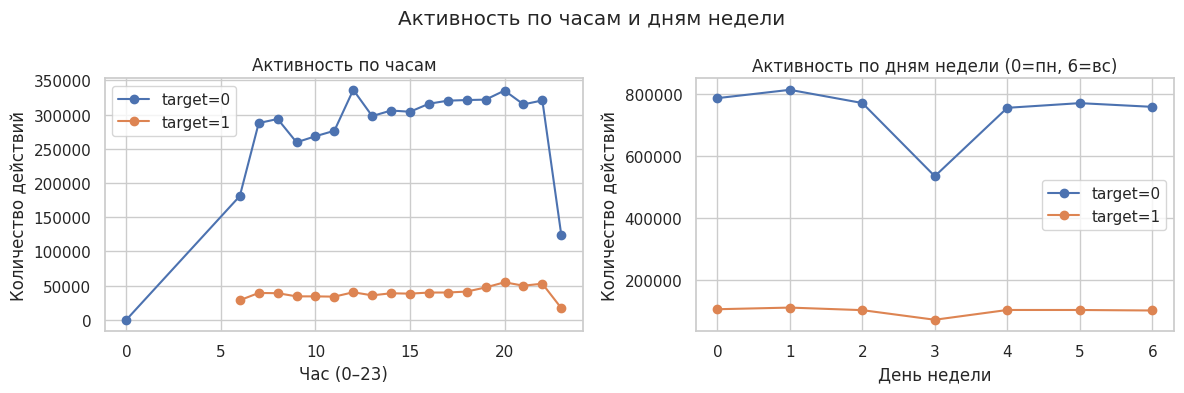

In [18]:
# активность по часам и дням недели с разделением по таргету

# группировка по часу и таргету
hour_target = df.groupby(['hour', 'target']).size().reset_index(name='count')
# группировка по дню недели и таргету
dow_target = df.groupby(['dayofweek', 'target']).size().reset_index(name='count')

fig3, (ax5, ax6) = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle('Активность по часам и дням недели')

for t in df['target'].unique():
    data_h = hour_target[hour_target['target'] == t]
    ax5.plot(data_h['hour'], data_h['count'], marker='o', label=f'target={t}')
ax5.set_title('Активность по часам')
ax5.set_xlabel('Час (0–23)')
ax5.set_ylabel('Количество действий')
ax5.legend()

for t in df['target'].unique():
    data_d = dow_target[dow_target['target'] == t]
    ax6.plot(data_d['dayofweek'], data_d['count'], marker='o', label=f'target={t}')
ax6.set_title('Активность по дням недели (0=пн, 6=вс)')
ax6.set_xlabel('День недели')
ax6.set_ylabel('Количество действий')
ax6.legend()

plt.tight_layout()
plt.show()

### Выводы по анализу признаков
- Типичный пользователь данной соцсети - это мужчина 24 лет, проживающий в России, использующий android. 
- Наибольшая активность пользователей отмечается в полдень и вечером в 20-21 часов, наименьшая - по средам.
- Насчет наименьшей активности по часам трудно что-то сказать, тк нельзя забывать, что у нас неравномерный срез по времени.
- Соотношение категорий таргетной переменной в разных группах пользователей визуально мало отличается, что говорит о необходимости генерации новых фичей, который бы лучше описывали поведение пользователя и особенности постов.

## Анализ взаимодействий

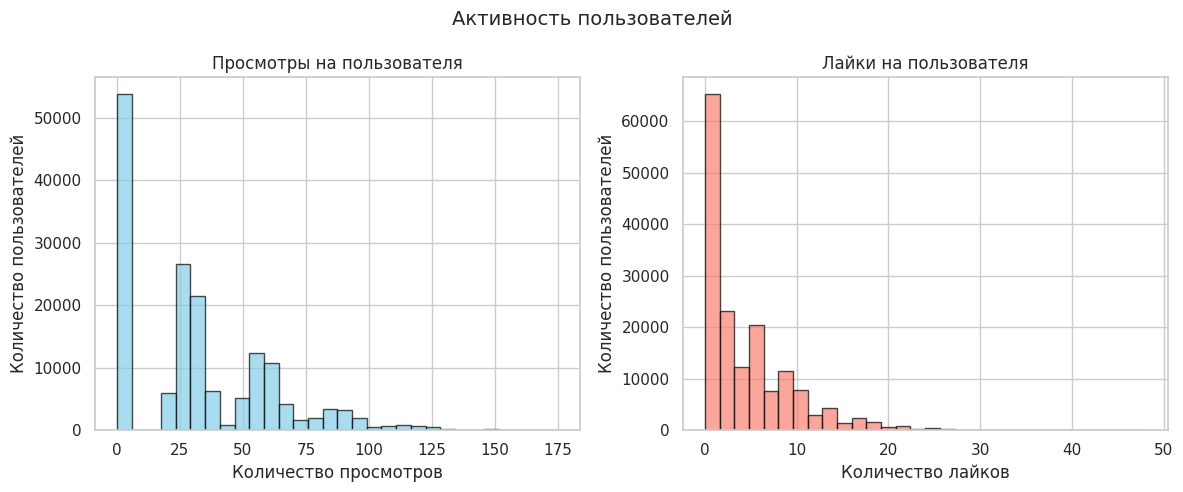

In [19]:
# расчет метрик на юзера
user_views = df[df['action'] == 'view'].groupby('user_id').size()
user_likes = df[df['action'] == 'like'].groupby('user_id').size()

user_metrics = pd.DataFrame({
    'views': user_views,
    'likes': user_likes
}).fillna(0)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig1.suptitle('Активность пользователей', fontsize=14)

ax1.hist(user_metrics['views'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax1.set_title('Просмотры на пользователя')
ax1.set_xlabel('Количество просмотров')
ax1.set_ylabel('Количество пользователей')

ax2.hist(user_metrics['likes'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
ax2.set_title('Лайки на пользователя')
ax2.set_xlabel('Количество лайков')
ax2.set_ylabel('Количество пользователей')

plt.tight_layout()
plt.show()

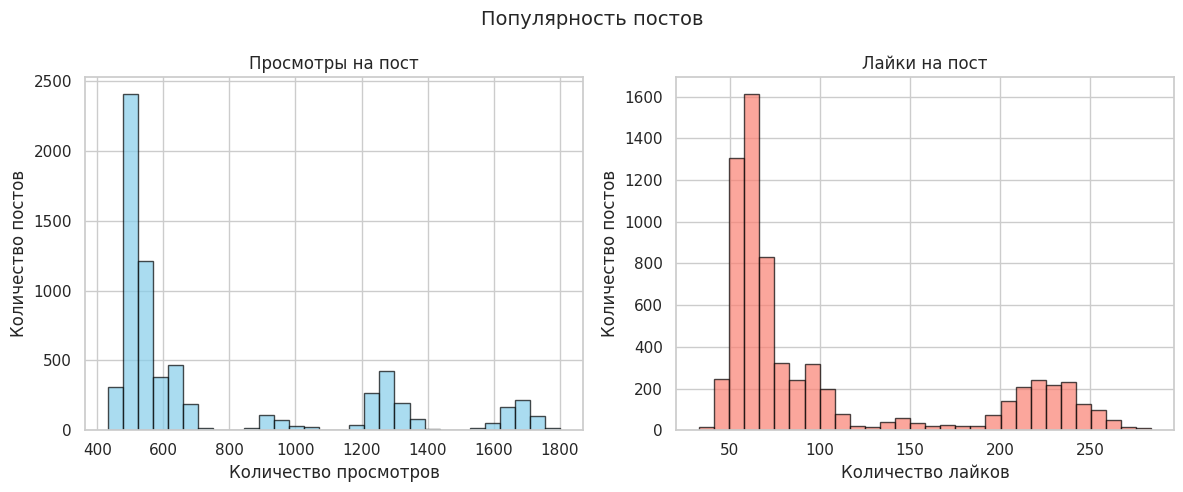

In [20]:
# расчет метрик на пост
post_views = df[df['action'] == 'view'].groupby('post_id').size()
post_likes = df[df['action'] == 'like'].groupby('post_id').size()

post_metrics = pd.DataFrame({
    'views': post_views,
    'likes': post_likes
}).fillna(0)

fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))
fig2.suptitle('Популярность постов', fontsize=14)

ax3.hist(post_metrics['views'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax3.set_title('Просмотры на пост')
ax3.set_xlabel('Количество просмотров')
ax3.set_ylabel('Количество постов')

ax4.hist(post_metrics['likes'], bins=30, alpha=0.7, color='salmon', edgecolor='black')
ax4.set_title('Лайки на пост')
ax4.set_xlabel('Количество лайков')
ax4.set_ylabel('Количество постов')

plt.tight_layout()
plt.show()

## Анализ текстов постов

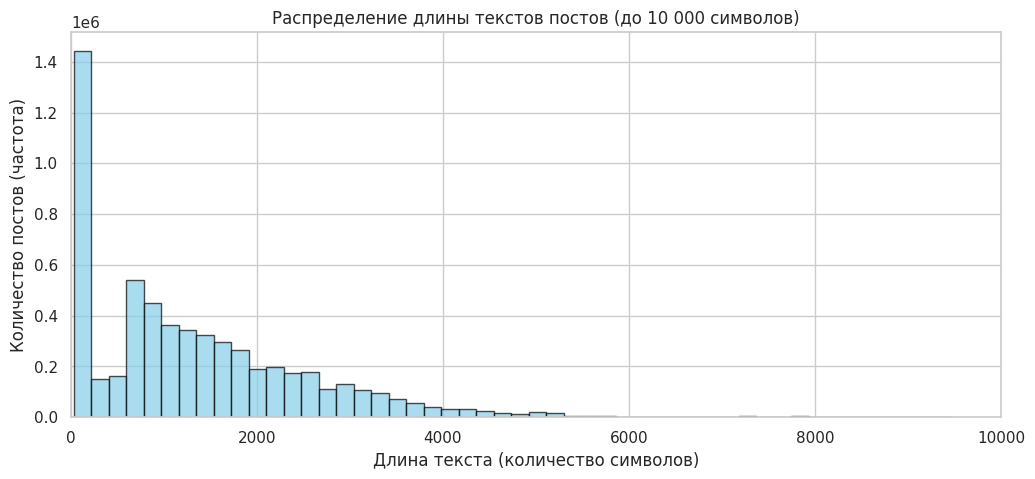

Постов длиннее 10000 символов: 8072 (0.14%)


In [21]:
df['text_len'] = df['text'].astype(str).apply(len)
len_subset = df['text_len'][df['text_len'] <= 10000] # ограничим для детализации

fig, ax = plt.subplots(figsize=(12,5))
plt.hist(len_subset, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.xlim(0, 10000)

plt.xlabel('Длина текста (количество символов)')
plt.ylabel('Количество постов (частота)')
plt.title('Распределение длины текстов постов (до 10 000 символов)')
plt.show()

long_posts = (df['text_len'] > 10000).sum()
print(f"Постов длиннее 10000 символов: {long_posts} ({long_posts/len(df)*100:.2f}%)")

Топ-10 самых частых слов: [('the', 277828), ('will', 17329), ('one', 13641), ('would', 13476), ('film', 12403), ('movie', 12102), ('out', 11062), ('people', 9050), ('can', 8454), ('time', 8379)]


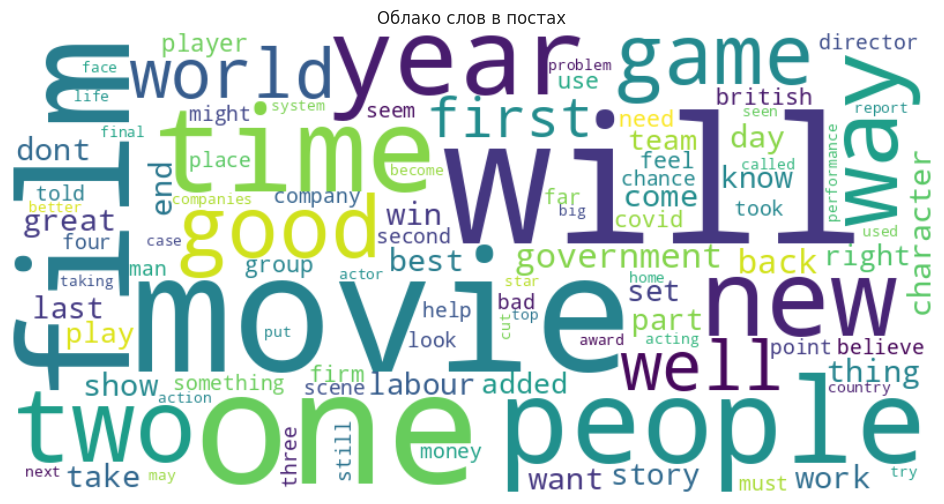

In [22]:
# для частотного анализа текста используем подвыборку - для экономии ресурсов
sample_size = min(20000, len(df))
text_sample = df['text'].sample(n=sample_size, random_state=42).astype(str)
text_sample = text_sample[text_sample.str.strip() != '']
    
if len(text_sample) > 0:
    def clean_text(txt):
        txt = txt.lower()
        txt = re.sub(r'[^a-z\s]', '', txt)  # английские буквы и пробелы
        words = txt.split()
        words = [w for w in words if w not in custom_stop_words and len(w) > 2]
        return ' '.join(words)
        
    all_words = ' '.join(text_sample.apply(clean_text)).split()
    word_freq = Counter(all_words)
    print("Топ-10 самых частых слов:", word_freq.most_common(10))
        
    from wordcloud import WordCloud
    text_for_cloud = ' '.join(all_words[:50000]) if len(all_words) > 50000 else ' '.join(all_words)
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100)
    wc.generate(text_for_cloud)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Облако слов в постах')
    plt.show()

# Выводы

In [23]:
report = f"""
=============================================================
                   ОТЧЕТ ПО РЕЗУЛЬТАТАМ EDA 
=============================================================
1. Общая информация:
   - Датасет содержит {df.shape[0]} записей, {df.shape[1]} колонок.
   - Временной диапазон: {df['timestamp'].min()} – {df['timestamp'].max()}
   - Дубликаты: {df.duplicated().sum()}

2. Пользователи и посты:
   - Уникальных пользователей: {len(user_views)}
   - Уникальных постов: {len(post_views)}
   - Среднее число просмотров на пользователя: {user_views.mean():.2f}
   - Медианное: {user_views.median():.1f}
   - Средняя популярность поста: {post_views.mean():.2f}, медиана: {post_views.median():.1f}

3. Временная динамика:
   - Пик активности приходится на час: {df['hour'].mode()[0]}
   - Наиболее активный день недели: {df['dayofweek'].mode()[0]} (0-пн)

4. Категориальные признаки:
   - Пол: {dict(df['gender'].value_counts())}
   - Возраст: средний {df['age'].mean():.1f}, разброс {df['age'].min()}–{df['age'].max()}
   - Страны: {df['country'].value_counts().to_dict()}
   - Экспериментальные группы: {dict(df['exp_group'].value_counts())}
   - ОС: {dict(df['os'].value_counts())}
   - Источник: {dict(df['source'].value_counts())}

5. Топики:
   - Всего топиков: {df['topic'].nunique()}
   - Самый популярный: {df['topic'].mode()[0]} 
     (доля {df['topic'].value_counts(normalize=True).max()*100:.1f}%)

6. Текстовые особенности:
   - Средняя длина текста: {df['text_len'].mean():.1f} символов
   - Топ-5 слов: {word_freq.most_common(5)}
   - Присутствуют как короткие новости, так и более длинные описания.
=============================================================
"""
print(report)


                   ОТЧЕТ ПО РЕЗУЛЬТАТАМ EDA 
1. Общая информация:
   - Датасет содержит 5890555 записей, 19 колонок.
   - Временной диапазон: 2021-10-27 16:42:51 – 2021-12-29 23:51:06
   - Дубликаты: 0

2. Пользователи и посты:
   - Уникальных пользователей: 158990
   - Уникальных постов: 6831
   - Среднее число просмотров на пользователя: 32.59
   - Медианное: 29.0
   - Средняя популярность поста: 758.54, медиана: 541.0

3. Временная динамика:
   - Пик активности приходится на час: 20
   - Наиболее активный день недели: 1 (0-пн)

4. Категориальные признаки:
   - Пол: {1: np.int64(3264436), 0: np.int64(2626119)}
   - Возраст: средний 27.2, разброс 14–95
   - Страны: {'Russia': 5130218, 'Ukraine': 312119, 'Belarus': 126681, 'Kazakhstan': 120710, 'Turkey': 62044, 'Finland': 59534, 'Azerbaijan': 54945, 'Latvia': 6396, 'Estonia': 6291, 'Switzerland': 5917, 'Cyprus': 5700}
   - Экспериментальные группы: {2: np.int64(1206000), 1: np.int64(1204965), 4: np.int64(1171876), 0: np.int64(1154034)